In [1]:
import os
# os.chdir removed — _bootstrap puts src/ on sys.path instead (D20)

In [2]:
import _bootstrap  # noqa: F401  — puts src/ on sys.path (see src/analysis/README.md)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import params
import pycountry as pc
import requests
import json
import time
import random
import os
import joblib
from scipy.optimize import nnls
dropbox_path = params.dropbox_path.parents[1]/'adolescent_modelling'
constructed_ages = [[25,49],[15,20],[21,49],[15,24],[25,34],[35,49]]


def save_model(model, file_path):
    joblib.dump(model, file_path)

def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None


def national_query_databse(args,collection_id):
    """
    get the dataframe of the response queried from args
    :param args: query args
    :return: dataframe of the response
    """

    try:
        response = requests.get(url="http://18.135.72.18/api/v1/query", params=args)
        response = response.json()
        decode_switch = True
    except:
        decode_switch = False
        data = ''

    if decode_switch:
        if response.get('status') == 200:
            data = pd.DataFrame(json.loads(response.get('data')))
            data = national_mark_behaviours(data)
            #data = data.loc[data['collection_id'] == collection_id,]

        else:
            data = response.get('status')
            print("error in query the database, status {}".format(data))
    return data


def national_mark_behaviours(data):
    '''
    if the behaviour code is found in the all_fields, mark the column & row as True
    :param data:
    :return:
    '''
    data['behaviour'] = [None] * len(data)

    for key in behaviour_dict.keys():

        condition_lst = [True if key in str(x) else False for x in data['all_fields']]
        data['behaviour'] = [key if y == True else x for x, y in zip(data['behaviour'], condition_lst)]

    # mark the rows without behaviour specification (in case there will be more counts)
    data['behaviour'] = ['non-behaviour' if 'behavior' not in str(y) else x for x, y in zip(data['behaviour'], data['targeting'])]
    if None in data['behaviour']:
        print('we have found behaviour not in records')
        print(data.loc[data['behaviour']==None,'all_fields'])
    return data


def national_query_args_generator(start_date, end_date, latest_database_switch):
    args = {
        "token": download_token,
        "platform": "instagram",
        "date_start": str(start_date),
        "date_end": str(end_date)
    }
    if latest_database_switch:
        args["collection"] = "dgg_national_ins"
    else:
        args["contributor_id"] = "5"
    return args


def preprocess_inquired_data(initialised_data):
    initialised_data['age_groups'] = [f'{x}_{y}' for x, y in zip(initialised_data['age_min'],initialised_data['age_max'])]
    temp = initialised_data.drop(columns=['collection_id', 'contributor_id', 'contributed_on',
           'timestamp', 'dau', 'mau','mau_lower','geo_locations', 'all_fields', 'targeting',
           'response'])
    temp = temp.drop_duplicates()
    temp['gender']= temp['gender'].astype(str)

    temp = temp.pivot(index= ['country'],values=['mau_upper'],columns =['collection_date','age_groups','behaviour','gender']).reset_index()
    temp.columns = ['country']+[f'{f"fb_{col[2]}" if col[3]=="non-behaviour" else behaviour_dict[col[3]][1]}_{gender_dict_reverse[col[4]]}' for col in temp.columns[1:].values]

    for col in temp.columns:
        if '_f' in col:
            temp[col.replace('_f','_r')] = temp[col]/temp[col.replace('_f','_m')]
    return temp

def dates_in_given_month(year,month):
    """
    return the date range in the given month
    """
    if month in [1, 3, 5, 7, 8, 10, 12]:
        return [x for x in range(1, 32)]
    elif month in [4, 6, 9, 11]:
        return [x for x in range(1, 31)]
    else:
        if year % 4 == 0:
            return [x for x in range(1, 30)]
        else:
            return [x for x in range(1, 29)]



In [3]:

import params

data_source = 'ins'

dropbox_fb_path  = params.dropbox_path.parents[2]/'pipeline'

fb_cols =["fb_18_999_men","fb_18_999_wom","fb_18_999_r"]
bg_cols = ['hdi','gdi','gdp_pcap','year']
model_specs = {'online': fb_cols,
               'offline': bg_cols,
               'combined_18_plus': fb_cols + bg_cols,
               'combined_18_plus_DHS_only': fb_cols + bg_cols,}


constructed_ages = [[25,49],[15,20],[21,49],[15,24],[25,34],[35,49]]
ins_ages={"fb_18_plus_with_ins_young_15_20":[[15,20]]}

df_ins = pd.read_csv(dropbox_path/'data/ins/ins_data_2025.csv')
df_ins.columns = [x.replace('fb','ins') for x in df_ins.columns]

model_specs['fb_18_plus_with_ins_young_15_20_r'] = bg_cols+ fb_cols+[f'ins_{ages[0]}_{ages[1]}_r' for ages in ins_ages['fb_18_plus_with_ins_young_15_20']]
df_pred = pd.DataFrame(columns=['indicator','age_range','model_type','outcome_var','iso3','year','month','pred'])


FileNotFoundError: [Errno 2] No such file or directory: '/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/adolescent_modelling/data/ins/ins_data_2025.csv'

In [4]:
indicator = 'internet'
model_type = "combined_18_plus_DHS_only"

In [5]:
df_fb_all = pd.read_csv(dropbox_path/'data/ins/imputed_final_all_ages_fb_data.csv')
df_outcomes = pd.read_csv(dropbox_path/f'data/outcome_var/{indicator}_adolescent.csv')
# firstly prepare background variables
df_outcomes['year']=df_outcomes['survey_start']
df_coefficients = pd.read_csv(dropbox_path/f'result/ins_error_coefficients_{model_type}_{indicator}.csv')

In [6]:
# firstly generating data
survey_year = 2025
df_background = pd.read_csv(dropbox_fb_path / f'model_fit/national/data/{indicator}/combined_multiple_years_no_missing_fb_aligned_{round(survey_year)}.csv')

if 'with_ins' in model_type:
    columns_to_combine = [f'ins_{ages[0]}_{ages[1]}_{var_type}' for ages in ins_ages[model_type.replace("_all","").replace("_r","")] for var_type in ["wom","men","r"]]
    df_outcomes = pd.merge(df_background,df_ins[['iso3']+columns_to_combine], on=['iso3'],how='left')
else:
    df_outcomes = df_background.copy()

df_outcomes['year']=survey_year
for col in ['fb_18_999_wom','fb_18_999_men','fb_18_999_r']:
    if col in df_outcomes.columns:
        df_outcomes.drop(columns=col,inplace=True)
df_outcomes = pd.merge(df_outcomes,df_fb_all[['iso3','year','fb_18_999_wom','fb_18_999_men','fb_18_999_r']], on=['iso3','year'],how='left')

#df_outcomes = pd.merge(df_background,df_fb_all[['iso3','year','fb_18_999_wom','fb_18_999_men','fb_18_999_r']], on=['iso3','year'],how='left').copy()


In [7]:
df_coefficients

,outcome_var,fb_18_999_men,fb_18_999_wom,fb_18_999_r,hdi,gdi,gdp_pcap,year
0,internet_fm_ratio_15_20,0.313884,0.0,0.000000,0.085813,0.000000,0.0,0.003701
1,internet_men_15_20,0.000000,0.0,0.011931,0.125399,0.000000,0.0,0.002814
2,internet_women_15_20,0.000000,0.0,0.110870,0.000000,0.007957,0.0,0.003514


In [8]:
constructed_ages = [[15,20]]

for i in range(len(constructed_ages)):
    age_max,age_min = constructed_ages[i][1],constructed_ages[i][0]
    age_range = f'{age_min}-{age_max}'
    for outcome_var in [f'{indicator}_fm_ratio_{age_min}_{age_max}',f'{indicator}_men_{age_min}_{age_max}',f'{indicator}_women_{age_min}_{age_max}']:

        model_spec = model_specs[model_type]
        model = load_model(dropbox_path/f'model/{model_type}/{outcome_var}.pkl')

        df_model = df_outcomes[['iso3']+model_spec].dropna(subset=model_spec).copy()
        df_model = df_model.drop_duplicates().reset_index(drop=True)
        df_model['year'] = df_model['year']-2015

        X_const = add_constant(df_model[model_spec])
        X_const['const'] = 1
        predictions = model.predict(X_const[model.params.index])

        #print(age_range,outcome_var)

        df_model['pred'] = predictions
        #df_model['residual'] = df_model[outcome_var] - df_model['pred']

        # predicted error

        coefficients= df_coefficients.loc[df_coefficients['outcome_var'] == outcome_var,model_spec].values[0]
        df_model['predicted_error'] = df_model[model_spec].values @ coefficients
        #data = data.merge(df_res[['country','pred','true','year']],on=['country','year'],how='left')


        temp_pred = df_model[['iso3','year','pred','predicted_error']].copy()
        temp_pred['year'] = temp_pred['year']+2015
        temp_pred['indicator']= indicator
        temp_pred['model_type']= model_type
        temp_pred['outcome_var'] = outcome_var
        temp_pred['age_range'] = age_range


        df_pred = pd.concat([df_pred,temp_pred])
        df_pred.reset_index(drop=True,inplace=True)

        #del temp_pred,df_model,X_const,model


NameError: name 'df_pred' is not defined

In [9]:
df_pred['pred'] = [max(0,x) for x in df_pred['pred']]
df_pred['pred'] = [min(1,x) for x in df_pred['pred']]
df_pred = df_pred.loc[df_pred['age_range'] == "15-20",]

NameError: name 'df_pred' is not defined

In [10]:
df_pred

NameError: name 'df_pred' is not defined

In [11]:
import pycountry as pc

countries= ['Indonesia', 'Philippines', 'Mongolia', 'Papua New Guinea', 'India', 'Nepal', 'Kenya', 'Tanzania', 'Burundi', 'Zambia', 'South Africa', 'Ukraine', 'Kyrgyzstan']
oky_countries = [pc.countries.lookup(x).alpha_3 for x in countries]


In [12]:
df_pred_oky = df_pred.loc[df_pred['iso3'].isin(oky_countries),]

NameError: name 'df_pred' is not defined

In [13]:
df_pred_oky.to_csv(dropbox_path/f'result/ins_pred_2025_oky_countries_DHS_only.csv',index=False)

NameError: name 'df_pred_oky' is not defined

In [14]:
df_pred_oky.loc[df_pred_oky['outcome_var'].str.contains('wom')]

NameError: name 'df_pred_oky' is not defined

# error predictions

In [15]:
model = load_model(str(params.EXTERNAL) + f"/national/adolescent_modelling/model/{model_type}/internet_women_15_20.pkl")

In [16]:
indicator = 'internet'

In [17]:
df_outcomes = pd.read_csv(dropbox_path/f'data/outcome_var/{indicator}_adolescent.csv')
if 'DHS' in model_type:
    df_outcomes = df_outcomes.loc[df_outcomes['survey'].str.contains('dhs'),]

df_outcomes['year']=df_outcomes['survey_start']
# firstly generating data
for survey_year in df_outcomes['year'].unique():
    df_background = pd.read_csv(dropbox_fb_path / f'model_fit/national/data/{indicator}/combined_multiple_years_no_missing_fb_aligned_{round(survey_year)}.csv')
    for ind,row in df_outcomes[df_outcomes['survey_start'] == survey_year].iterrows():
        if row['iso3'] not in params.sanction_countries+['CUB','IRN','PRK','SYR','SDN','VEN']:

            for var in bg_cols:
                if var!='year':
                    df_outcomes.loc[ind,var] = df_background.loc[df_background['iso3'] == row['iso3'],var].values[0]

            if 'with_ins' in model_type:
                for ages in ins_ages[model_type]:
                    for var_type in ["wom","men","r"]:
                        var_name = f'fb_{ages[0]}_{ages[1]}_{var_type}'
                        df_outcomes.loc[ind,f'ins_{ages[0]}_{ages[1]}_{var_type}'] = df_ins.loc[(df_ins['iso3'] == row['iso3']),var_name].values[0]

df_outcomes = pd.merge(df_outcomes,df_fb_all[['iso3','year','fb_18_999_wom','fb_18_999_men','fb_18_999_r']], on=['iso3','year'],how='left')


In [18]:
df_coefficients = pd.DataFrame(columns=[['outcome_var']+model_spec])

In [19]:
age_min,age_max = 15,20
for outcome_var in [f'{indicator}_fm_ratio_{age_min}_{age_max}',f'{indicator}_men_{age_min}_{age_max}',f'{indicator}_women_{age_min}_{age_max}']:

    model = load_model(dropbox_path/f'model/{model_type}/{outcome_var}.pkl')

    df_to_model = df_outcomes[['iso3',outcome_var]+model_spec].dropna(subset=model_spec).copy()
    df_to_model['year'] = df_to_model['year']-2015

    X_const = add_constant(df_to_model[model_spec])
    X_const['const'] = 1
    predictions = model.predict(X_const[model.params.index])
    df_to_model['predicted']= predictions

    df_to_model['abs_diff'] = np.abs(df_to_model[outcome_var] - df_to_model['predicted'])
    coefficients, residual = nnls(df_to_model[list(model_spec)], df_to_model['abs_diff'])
    residual_pred = df_to_model[list(model_spec)] @ coefficients

    df_to_model['predicted_error'] = residual_pred
    df_coefficients.loc[len(df_coefficients),] = [outcome_var]+list(coefficients)



In [20]:
df_coefficients.to_csv(dropbox_path/f'result/ins_error_coefficients_{model_type}_{indicator}.csv',index=False)

# Comparisons

In [21]:
import pandas as pd
# FIXME (D20): input read from ~/Downloads — not reproducible, no shared location known
df_adolescent = pd.read_csv('/Users/valler/Downloads/predictions_with_uncertainty_pop.csv')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/valler/Downloads/predictions_with_uncertainty_pop.csv'

In [22]:
region_dict = {x: y for x, y in zip(df_adolescent['gid_0'], df_adolescent['region'])}

NameError: name 'df_adolescent' is not defined

In [23]:
df_adolescent= df_adolescent[['gid_1', 'predicted', 'predicted_error','country','pop_15_to_20_female','region']]
df_adolescent['national_pop'] = df_adolescent.groupby('gid_0')['pop_15_to_20_female'].transform('sum')
df_adolescent['national_pop'] = df_adolescent['national_pop']/2

df_adolescent['national_portion'] = df_adolescent['predicted'] / df_adolescent['national_pop'] * df_adolescent['pop_15_to_20_female']

NameError: name 'df_adolescent' is not defined

In [24]:
df_adolescent_aggregated = df_adolescent.groupby(['gid_0','outcome'])['national_portion'].sum().reset_index().sort_values(by='national_portion',ascending=False)

NameError: name 'df_adolescent' is not defined

In [25]:
df_adult = pd.read_csv(params.EXTERNAL / 'pipeline/result/subnational/aggregate_files.csv')
#df_adult.rename(columns={'predicted':'predicted_18_49'},inplace=True)
df_pop = pd.read_csv(str(params.EXTERNAL / "pipeline/preprocessed/subnational") + "/subnational_features_202501.csv")

df_adult = df_adult.loc[(df_adult['date'] == '2025-01') & (df_adult['outcome'].str.contains('women')),]

df_adolescent['outcome']= df_adolescent['outcome'].str.replace('_15_20','')
df_adult = pd.merge(df_adult[['gid_0','gid_1', 'outcome', 'predicted']],df_pop[['gadm','pop_all_age_female']],left_on=['gid_1'],right_on=['gadm'],how='left')


NameError: name 'df_adolescent' is not defined

In [26]:
df_adult['national_pop'] = df_adult.groupby('gid_0')['pop_all_age_female'].transform('sum')
df_adult['national_pop'] = df_adult['national_pop']/2

df_adult['national_portion'] = df_adult['predicted'] / df_adult['national_pop'] * df_adult['pop_all_age_female']

KeyError: 'Column not found: pop_all_age_female'

In [27]:
df_adult_aggregated = df_adult.groupby(['gid_0','outcome'])['national_portion'].sum().reset_index().sort_values(by='national_portion',ascending=False)

KeyError: 'Column not found: national_portion'

In [28]:

df_all = pd.merge(df_adult_aggregated,df_adolescent_aggregated,on=['gid_0','outcome'],how='left',suffixes=['_adult','_adolescent'])

NameError: name 'df_adult_aggregated' is not defined

In [29]:
import utils

# Add a new column for continent
df_all['region'] = df_all['gid_0'].apply(lambda x: region_dict.get(x))


NameError: name 'df_all' is not defined

In [30]:
df_all['outcome'] = df_all['outcome'].str.replace('_women','')
df_all['outcome'] = [x.capitalize() for x in df_all['outcome']]

NameError: name 'df_all' is not defined

In [31]:
df_all['difference'] = df_all['national_portion_adolescent'] - df_all['national_portion_adult']
top_5_different = df_all.sort_values(by='difference', ascending=False).head(3)['gid_0'].tolist()


NameError: name 'df_all' is not defined

In [32]:

top_5_different

NameError: name 'top_5_different' is not defined

In [33]:
highlight_countries = set(['NGA', 'KEN', 'IND', 'PAK', 'ETH', 'TZA']+top_5_different)

#top_5_different = df_all.loc[].sort_values(by='national_portion_adolescent',ascending=False).head(5)

NameError: name 'top_5_different' is not defined

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set outcome display order
desired_order = ['Internet', 'Mobile']

# Set up FacetGrid
g = sns.FacetGrid(
    df_all,
    col='outcome',
    hue='region',
    col_order=desired_order,
    height=3.5,
    sharey=True,sharex=True

)
# Add diagonal dashed line (y = x) to each subplot
def diag_line(*args, **kwargs):
    ax = plt.gca()
    limits = [
        1,
        0
    ]
    ax.plot(limits, limits, linestyle='--', color='black', linewidth=1, alpha=0.9)


g.map(diag_line)

# Plot scatterplots
g.map_dataframe(
    sns.scatterplot,
    x='national_portion_adult',
    y='national_portion_adolescent',
    alpha=1,
    s=20
)


# Set axis labels and title
g.set_axis_labels('', 'Subnational Aggregated (Age 15-20)')
# Manually set titles with grey background
for ax in g.axes.flat:
    title_text = ax.get_title()  # Get current title (e.g., 'outcome = Internet')
    clean_title = title_text.replace('outcome = ', '')  # Clean label if needed
    ax.set_title(
        '                                  '+clean_title+'                            ',
        fontsize=10,
        loc='left',
        bbox=dict(facecolor='lightgrey', edgecolor='lightgrey', boxstyle='round,pad=0',linewidth=2)
    )

#g.fig.suptitle("Adolescent vs.  Adult Digital Adoption", fontsize=12,fontweight='bold')
# Remove the previous centered title
# g.fig.suptitle(...)

# Add a left-aligned title at the top-left corner of the plotting area
g.fig.text(
    x=0.1, y=0.93,  # Adjust x for left alignment, y for vertical position
    s="Adolescent vs. Adult Digital Adoption",
    fontsize=12,
    fontweight='bold',
    ha='left'  # Ensure horizontal alignment is left
)

# Left-aligned title with grey background box

plt.subplots_adjust(top=0.85)

g.add_legend(
    title='Region',
    loc='lower center',
    bbox_to_anchor=(0.3, -0.2),  # Adjust vertical spacing as needed
    ncol=3,                      # Optional: put legend in one row
    frameon=False
)

g.fig.text(
    0.33, 0.07,  # X = center, Y = below plot area
    'Subnational Aggregated (Age 18–49)',
    ha='center',
    va='center',
    fontsize=11
)

for ax in g.axes.flat:
    # Get the outcome (column facet)
    outcome = ax.get_title().replace('outcome = ', '').strip()

    # Subset data for this outcome only
    subset = df_all[df_all['outcome'] == outcome]

    # Filter to the countries you want to annotate
    highlight_df = subset[subset['gid_0'].isin(highlight_countries)]

    # Add text labels for each country
    for _, row in highlight_df.iterrows():
        ax.text(
            row['national_portion_adult'],
            row['national_portion_adolescent'] if row['gid_0']!='PAK' else row['national_portion_adolescent']*0.9,  # Adjust Pakistan's label position
            row['gid_0'],  # Or use a cleaner label if needed
            fontsize=7,
            weight='bold',
            ha='left',
            va='bottom',
            color='red'
        )

# Turn axis lines (spines) black & remove grid
for ax in g.axes.flat:
    ax.spines['top'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.grid(alpha=0)  # Set grid alpha to 0 (invisible)

plt.savefig(params.FIG / 'age_15_20_adolescent_vs_adult.png', dpi=300, bbox_inches='tight')

NameError: name 'df_all' is not defined

# fb counts comparisons

In [35]:
date = '202501'
dropbox_path = params.dropbox_path.parents[2]/'pipeline'
adolescent_group = '13-19'
adult_group = '20_plus'
#oky_countries = ['IDN', 'PHL', 'MNG', 'PNG', 'IND', 'NPL', 'KEN', 'TZA', 'BDI', 'ZMB', 'ZAF', 'UKR', 'KGZ']
oky_countries = ['MDG','CIV','IDN', 'PHL', 'MNG', 'PNG', 'IND', 'NPL', 'KEN', 'TZA', 'BDI', 'ZMB', 'ZAF', 'UKR', 'KGZ']

In [36]:
# prepare the UN population data for adolescent group
df_unpop = pd.read_csv(params.dropbox_path.parents[1]/'adolescent_modelling/data/file/un_1950_2023_processed.csv')
df_unpop.columns = [x.lower().replace("_m","_men").replace("_f","_women").replace('inf',"plus") for x in df_unpop.columns]
df_unpop['year']=df_unpop['year'].astype(int)
df_unpop = df_unpop.loc[df_unpop['year'] == 2023,]

for gender in ['men','women']:
    df_unpop[f'13_19_{gender}'] = df_unpop[f'13_14_{gender}'] + df_unpop[f'14_15_{gender}'] + df_unpop[f'15_19_{gender}']
    df_unpop[f'13_plus_{gender}'] = df_unpop[f'13_19_{gender}']+df_unpop[f'20_plus_{gender}']


In [37]:
# prepare the FB data for adolescent group
df_fb = pd.DataFrame()
for month in range(1,13):
    df_fb = pd.concat([df_fb,pd.read_csv(dropbox_path/f"averaged/national/mau_upper_2024{str(month).zfill(2)}_averaged.csv")])

df_fb = pd.concat([df_fb,pd.read_csv(dropbox_path/f"averaged/national/mau_upper_202501_averaged.csv")])

df_fb.columns = [x.replace('FB_age_','') for x in df_fb.columns]


for gender in ['men','women']:
    df_fb[f'13_19_{gender}'] = df_fb[f'13_14_{gender}'] + df_fb[f'14_15_{gender}'] + df_fb[f'15_19_{gender}']
    df_fb[f'13_plus_{gender}'] = df_fb[f'13_19_{gender}']+df_fb[f'20_plus_{gender}']

df_fb_display = df_fb[['Country','13_19_men','13_19_women','20_plus_women','20_plus_men','13_plus_women','13_plus_men']].groupby(['Country']).mean().reset_index().copy()
df_fb_display.drop(df_fb_display.loc[df_fb_display['Country']=='AN'].index,inplace=True)


import pycountry as pc
# raw count displaying
df_fb_display['iso3']=[None if pd.isnull(x) else pc.countries.get(alpha_2=x).alpha_3 if x not in ['AN', 'XK'] else {'AN': 'ANT', 'XK': 'XKX'}[x] for x in df_fb_display['Country']]
df_fb_display = df_fb_display.loc[df_fb_display['iso3'].isin(oky_countries),]
df_fb_display = df_fb_display.merge(df_unpop[['iso3','13_19_men','13_19_women','20_plus_men','20_plus_women','13_plus_women','13_plus_men']], on=['iso3'], how='left',suffixes=['','_unpop'])

# adjusting by UN population data
for col in ['13_19_men','13_19_women','20_plus_men','20_plus_women','13_plus_women','13_plus_men']:
    df_fb_display[col+'_adj'] = df_fb_display[col]/ (df_fb_display[col+'_unpop'])



In [38]:
# saving the results to the dropbox
df_fb_display.to_csv(dropbox_path.parent/f'funder_requests/ins_fb_penetration/fb_adolescent_2024-2025_averaged.csv',index=False)

In [39]:
# now get the ins data
df_ins = pd.DataFrame()
for month in range(1,13):
    df_ins = pd.concat([df_ins,pd.read_csv(str(params.EXTERNAL) + f'/national/adolescent_modelling/data/ins/averaged/2024-{str(month).zfill(2)}_averaged.csv')])
df_ins = pd.concat([df_ins,pd.read_csv(str(params.EXTERNAL) + '/national/adolescent_modelling/data/ins/averaged/2025-01_averaged.csv')])
df_ins.columns = [x.replace('fb_','').replace('_m','_men').replace('_f','_women').replace('999','plus') for x in df_ins.columns]


for gender in ['men','women']:
    df_ins[f'13_19_{gender}'] = df_ins[f'13_14_{gender}'] + df_ins[f'14_15_{gender}'] + df_ins[f'15_19_{gender}']
    df_ins[f'13_plus_{gender}'] = df_ins[f'13_19_{gender}']+df_ins[f'20_plus_{gender}']
    
    
df_ins_display = df_ins[['iso3','13_19_women','13_19_men','20_plus_men','20_plus_women','13_plus_women','13_plus_men']].copy()
df_ins_display = df_ins_display.groupby(['iso3']).mean().reset_index()
df_ins_display = df_ins_display.loc[df_ins_display['iso3'].isin(oky_countries),]
df_ins_display = df_ins_display.merge(df_unpop[['iso3','13_19_men','13_19_women','20_plus_men','20_plus_women','13_plus_women','13_plus_men']], on=['iso3'], how='left',suffixes=['','_unpop'])

# adjusted count displaying
for col in ['13_19_men','13_19_women','20_plus_men','20_plus_women','13_plus_women','13_plus_men']:
    df_ins_display[col+'_adj'] = df_ins_display[col]/ (df_ins_display[col+'_unpop'])


In [40]:
# optionally save the ins data
# saving the results to the dropbox
df_ins_display.to_csv(dropbox_path.parent/f'funder_requests/ins_fb_penetration/ins_adolescent_2024-2025_averaged.csv',index=False)

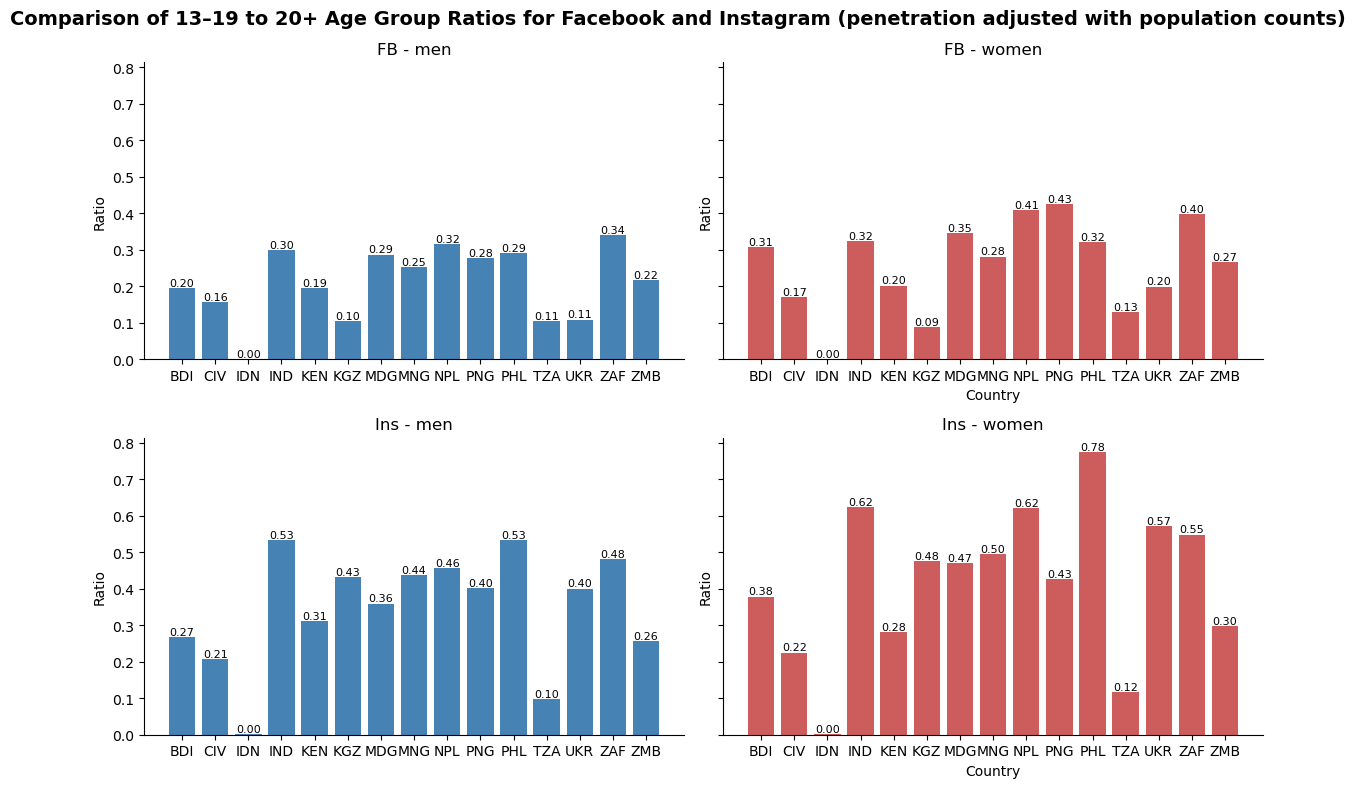

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt
import numpy as np

adj_contrl= True  # Set to True if you want to use adjusted values, False for raw counts
# Calculate ratios
df_fb_display['men_ratio'] = df_fb_display[f'13_19_men_{"adj" if adj_contrl else ""}'] / df_fb_display[f'20_plus_men_{"adj" if adj_contrl else ""}']
df_fb_display['women_ratio'] = df_fb_display[f'13_19_women_{"adj" if adj_contrl else ""}'] / df_fb_display[f'20_plus_women_{"adj" if adj_contrl else ""}']


df_ins_display['men_ratio'] = df_ins_display[f'13_19_men_{"adj" if adj_contrl else ""}'] / df_ins_display[f'20_plus_men_{"adj" if adj_contrl else ""}']
df_ins_display['women_ratio'] = df_ins_display[f'13_19_women_{"adj" if adj_contrl else ""}'] / df_ins_display[f'20_plus_women_{"adj" if adj_contrl else ""}']


# Set up the figure and subplots
fig, ax = plt.subplots(2,2, figsize=(12,8),sharey=True)
axs = ax.flatten()
# Extract x-axis values (countries)
countries = df_fb_display['iso3']
x = np.arange(len(countries))


# --- Subplot 1: Men ratio ---
men_ratios = df_fb_display['men_ratio']
axs[0].bar(x, men_ratios, color='steelblue')
axs[0].set_title('FB - men')
axs[0].set_ylabel('Ratio')
axs[0].grid(axis='y', linestyle='--', alpha=0)

axs[0].set_xticks(x)
axs[0].set_xticklabels(countries, rotation=0, ha='center')



# Add annotations for men
for i, ratio in enumerate(men_ratios):
    axs[0].text(x[i], ratio + 0.0005, f"{ratio:.2f}", ha='center', va='bottom', fontsize=8)

# --- Subplot 2: Women ratio ---
women_ratios = df_fb_display['women_ratio']
axs[1].bar(x, women_ratios, color='indianred')
axs[1].set_title('FB - women')
axs[1].set_xlabel('Country')
axs[1].set_ylabel('Ratio')
axs[1].grid(axis='y', linestyle='--', alpha=0)

# Set ticks only once (on one axis, ideally the bottom one)
axs[1].set_xticks(x)
axs[1].set_xticklabels(countries, rotation=0, ha='center')

# Add annotations for women
for i, ratio in enumerate(women_ratios):
    axs[1].text(x[i], ratio + 0.0005, f"{ratio:.2f}", ha='center', va='bottom', fontsize=8)


# --- Subplot 1: Men ratio ---
men_ratios = df_ins_display['men_ratio']
axs[2].bar(x, men_ratios, color='steelblue')
axs[2].set_title('Ins - men')
axs[2].set_ylabel('Ratio')
axs[2].grid(axis='y', linestyle='--', alpha=0)
axs[2].set_xticks(x)
axs[2].set_xticklabels(countries, rotation=0, ha='center')


# Add annotations for men
for i, ratio in enumerate(men_ratios):
    axs[2].text(x[i], ratio + 0.0005, f"{ratio:.2f}", ha='center', va='bottom', fontsize=8)

# --- Subplot 2: Women ratio ---
women_ratios = df_ins_display['women_ratio']
axs[3].bar(x, women_ratios, color='indianred')
axs[3].set_title('Ins - women')
axs[3].set_xlabel('Country')
axs[3].set_ylabel('Ratio')
axs[3].grid(axis='x', linestyle='--', alpha=0)

# Set ticks only once (on one axis, ideally the bottom one)
axs[3].set_xticks(x)
axs[3].set_xticklabels(countries, rotation=0, ha='center')

# Add annotations for women
for i, ratio in enumerate(women_ratios):
    axs[3].text(x[i], ratio + 0.0005, f"{ratio:.2f}", ha='center', va='bottom', fontsize=8)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.grid(alpha=0)

plt.suptitle(f'Comparison of 13–19 to 20+ Age Group Ratios for Facebook and Instagram {"(penetration adjusted with population counts)" if adj_contrl else ""}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.savefig(dropbox_path.parent / f"funder_requests/ins_fb_penetration/MDG_and_CIV/age_13_19_to_20_plus_penetration_ratio.png", dpi=300, bbox_inches='tight')

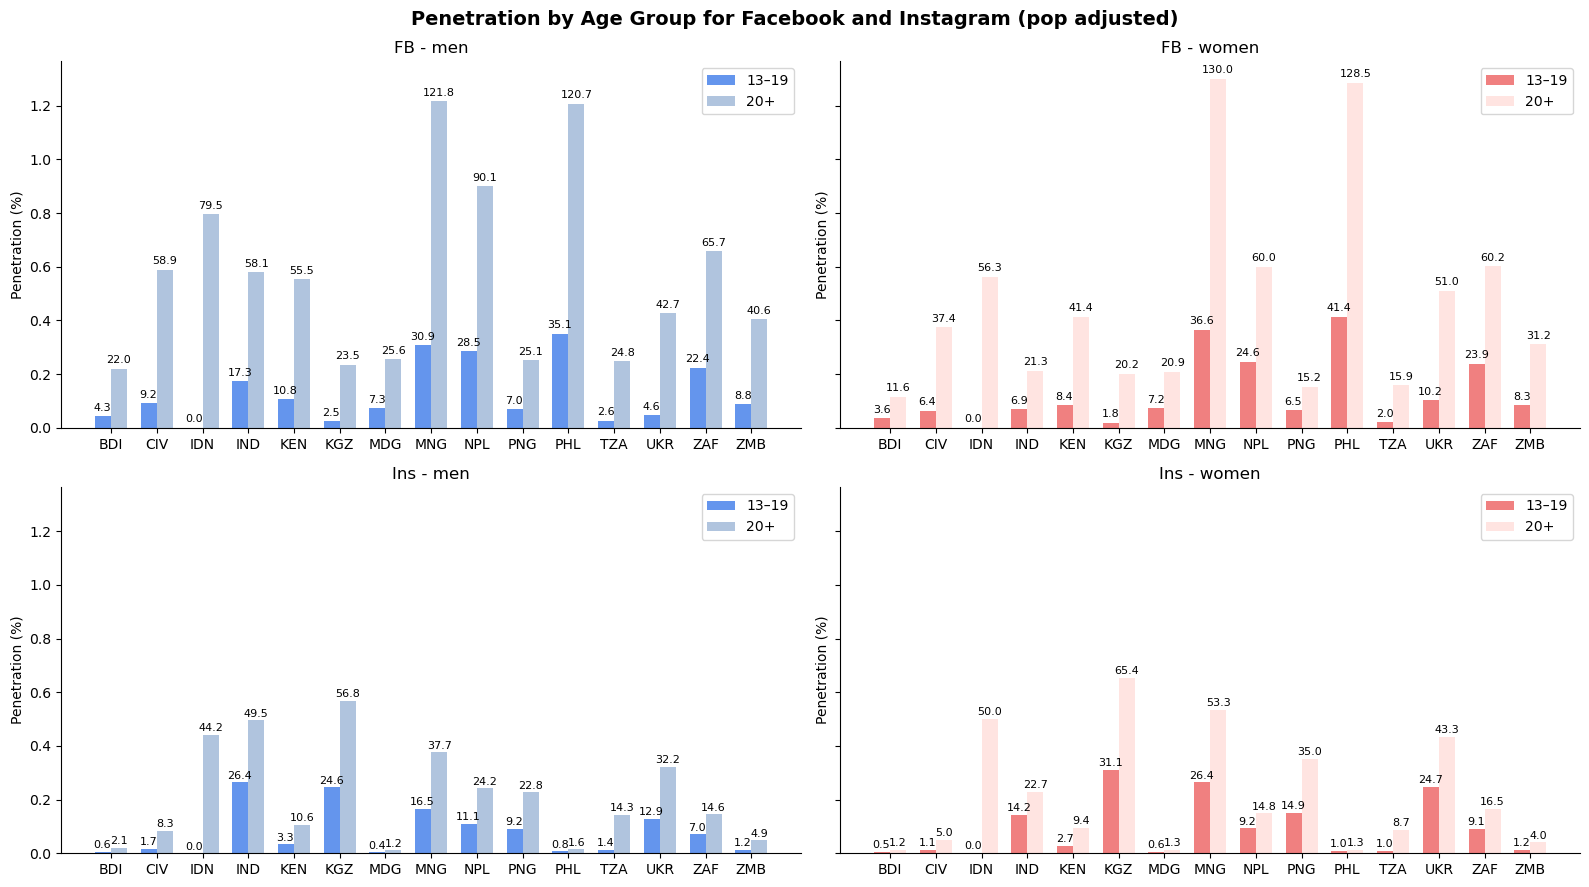

In [42]:
import matplotlib.pyplot as plt
import numpy as np

adj_contrl = True  # Set to True if using adjusted values

# Set column suffix
suffix = "_adj" if adj_contrl else ""

# Set up the figure and subplots
fig, ax = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
axs = ax.flatten()

# Extract x-axis values (countries)
countries = df_fb_display['iso3']
x = np.arange(len(countries))
bar_width = 0.35  # width of each bar

# Helper function to plot grouped bars
def plot_counts(ax, df, platform_label, gender, color1, color2):
    age_13_19 = df[f'13_19_{gender}{suffix}']
    age_20_plus = df[f'20_plus_{gender}{suffix}']

    ax.bar(x - bar_width/2, age_13_19, width=bar_width, label='13–19', color=color1)
    ax.bar(x + bar_width/2, age_20_plus, width=bar_width, label='20+', color=color2)

    ax.set_title(f'{platform_label} - {gender}')
    ax.set_ylabel('Penetration (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(countries, rotation=0, ha='center')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    ax.legend()  # <-- Add legend here

    # Annotate values
    for i in range(len(countries)):
        ax.text(x[i] - bar_width/2-0.01, age_13_19.iloc[i] + 0.01 * max(age_13_19.max(), age_20_plus.max()), f"{age_13_19.iloc[i]*100:.1f}", ha='center', va='bottom', fontsize=8)
        ax.text(x[i] + bar_width/2, age_20_plus.iloc[i] + 0.01 * max(age_13_19.max(), age_20_plus.max()), f"{age_20_plus.iloc[i]*100:.1f}", ha='center', va='bottom', fontsize=8)

# Plot all 4 subplots
plot_counts(axs[0], df_fb_display, "FB", "men", "cornflowerblue", "lightsteelblue")
plot_counts(axs[1], df_fb_display, "FB", "women", "lightcoral", "mistyrose")
plot_counts(axs[2], df_ins_display, "Ins", "men", "cornflowerblue", "lightsteelblue")
plot_counts(axs[3], df_ins_display, "Ins", "women", "lightcoral", "mistyrose")

# Formatting
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.grid(alpha=0)

plt.suptitle(f'Penetration by Age Group for Facebook and Instagram {"(pop adjusted)" if adj_contrl else "(raw counts)"}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(dropbox_path.parent / f"funder_requests/ins_fb_penetration/age_13_19_penetration_comparison.png", dpi=300, bbox_inches='tight')

In [43]:
df_fb_display = df_fb_display[['iso3', '13_19_men', '13_19_women', '20_plus_women', '20_plus_men', '13_19_men_unpop',
       '13_19_women_unpop', '20_plus_men_unpop', '20_plus_women_unpop',
        '13_19_men_adj',
       '13_19_women_adj', '20_plus_men_adj', '20_plus_women_adj']].copy()

In [44]:
df_fb_display.columns = ["iso3"] + ["fb_"+x if not (( "_adj"  in x ) | ("_unpop"  in x) ) else x for x in df_fb_display.columns[1:]]
df_fb_display

,iso3,fb_13_19_men,fb_13_19_women,fb_20_plus_women,fb_20_plus_men,13_19_men_unpop,13_19_women_unpop,20_plus_men_unpop,20_plus_women_unpop,13_19_men_adj,13_19_women_adj,20_plus_men_adj,20_plus_women_adj
0,BDI,6.231375e+04,5.153793e+04,3.450346e+05,6.298361e+05,1447987.0,1444493.0,2859329.0,2983123.0,0.043035,0.035679,0.220274,0.115662
1,CIV,2.893520e+05,1.893297e+05,2.716042e+06,4.463767e+06,3131795.0,2963086.0,7579584.0,7253852.0,0.092392,0.063896,0.588920,0.374428
2,IDN,6.669734e+03,6.101963e+03,5.291057e+07,7.383481e+07,21489631.0,20406804.0,92837398.0,93959280.0,0.000310,0.000299,0.795313,0.563122
3,IND,2.088820e+07,7.573490e+06,9.762703e+07,2.803174e+08,120592098.0,109600168.0,482505155.0,458638608.0,0.173214,0.069101,0.580963,0.212863
4,KEN,6.292781e+05,4.875974e+05,5.857189e+06,7.608447e+06,5838368.0,5835499.0,13717648.0,14136194.0,0.107783,0.083557,0.554647,0.414340
5,KGZ,1.393157e+04,9.609370e+03,4.331492e+05,4.693695e+05,563810.0,534543.0,1993454.0,2148177.0,0.024710,0.017977,0.235455,0.201636
6,MDG,2.275619e+05,2.202032e+05,1.608972e+06,1.944692e+06,3098486.0,3042261.0,7594569.0,7684687.0,0.073443,0.072381,0.256064,0.209374
7,MNG,7.763058e+04,8.590822e+04,1.363466e+06,1.219417e+06,251525.0,234954.0,1001354.0,1048610.0,0.308640,0.365638,1.217768,1.300260
8,NPL,7.776009e+05,6.574810e+05,5.841708e+06,7.551010e+06,2728303.0,2676590.0,8380463.0,9734924.0,0.285013,0.245641,0.901025,0.600077
9,PNG,6.889709e+04,5.802902e+04,4.305824e+05,7.387416e+05,988485.0,893795.0,2945540.0,2826252.0,0.069700,0.064924,0.250800,0.152351


In [45]:
df_fb_display.to_csv(dropbox_path.parent / f"funder_requests/ins_fb_penetration/fb_13_19_20_plus_{date}_averaged.csv", index=False)

In [46]:

df_ins_display = df_ins_display[['iso3', '13_19_men', '13_19_women', '20_plus_women', '20_plus_men',
        '13_19_men_unpop',
       '13_19_women_unpop', '20_plus_men_unpop', '20_plus_women_unpop',
         '13_19_men_adj',
       '13_19_women_adj', '20_plus_men_adj', '20_plus_women_adj']].copy()


In [47]:
#df_ins_display.columns = ["iso3"] + ["ins_"+x if (( "_adj" not in x ) | ("_unpop" not in x) ) else x for x in df_ins_display.columns[1:]]
#df_ins_display.columns = df_ins_display.columns.str.replace('ins_', '', regex=False)
df_ins_display.columns = ["iso3"] + ["ins_"+x if not (( "_adj"  in x ) | ("_unpop"  in x) ) else x for x in df_ins_display.columns[1:]]
df_ins_display

,iso3,ins_13_19_men,ins_13_19_women,ins_20_plus_women,ins_20_plus_men,13_19_men_unpop,13_19_women_unpop,20_plus_men_unpop,20_plus_women_unpop,13_19_men_adj,13_19_women_adj,20_plus_men_adj,20_plus_women_adj
0,BDI,8.252825e+03,6.794255e+03,3.703262e+04,6.076955e+04,1447987.0,1444493.0,2859329.0,2983123.0,0.005700,0.004704,0.021253,0.012414
1,CIV,5.387480e+04,3.353664e+04,3.649095e+05,6.309922e+05,3131795.0,2963086.0,7579584.0,7253852.0,0.017203,0.011318,0.083249,0.050306
2,IDN,6.595520e+03,8.472304e+03,4.699019e+07,4.103624e+07,21489631.0,20406804.0,92837398.0,93959280.0,0.000307,0.000415,0.442023,0.500112
3,IND,3.186925e+07,1.553976e+07,1.043238e+08,2.390574e+08,120592098.0,109600168.0,482505155.0,458638608.0,0.264273,0.141786,0.495451,0.227464
4,KEN,1.929603e+05,1.551494e+05,1.331462e+06,1.451566e+06,5838368.0,5835499.0,13717648.0,14136194.0,0.033050,0.026587,0.105817,0.094188
5,KGZ,1.387887e+05,1.664912e+05,1.404568e+06,1.132754e+06,563810.0,534543.0,1993454.0,2148177.0,0.246162,0.311465,0.568237,0.653842
6,MDG,1.320929e+04,1.868956e+04,1.002391e+05,9.000812e+04,3098486.0,3042261.0,7594569.0,7684687.0,0.004263,0.006143,0.011852,0.013044
7,MNG,4.154723e+04,6.206446e+04,5.594103e+05,3.772364e+05,251525.0,234954.0,1001354.0,1048610.0,0.165181,0.264156,0.376726,0.533478
8,NPL,3.022459e+05,2.472440e+05,1.445074e+06,2.027912e+06,2728303.0,2676590.0,8380463.0,9734924.0,0.110782,0.092373,0.241981,0.148442
9,PHL,9.458054e+05,1.500341e+06,1.246983e+07,7.878374e+06,10314623.0,10059617.0,34581350.0,35595080.0,0.091696,0.149145,0.227821,0.350325


In [48]:
#df_ins_display.columns = ["iso3"] + ["ins_"+x if (( "_adj" not in x ) | ("_unpop" not in x) ) else x for x in df_ins_display.columns[1:]]
df_ins_display.to_csv(dropbox_path.parent / f"funder_requests/ins_fb_penetration/ins_13_19_20_plus_{date}_averaged.csv", index=False)

In [49]:
import matplotlib.pyplot as plt
import numpy as np

adj_contrl= True  # Set to True if you want to use adjusted values, False for raw counts
# Calculate ratios



df_fb_display['men_ratio'] = df_fb_display[f'13_19_men_{"adj" if adj_contrl else ""}'] /( df_fb_display[f'13_plus_men_{"adj" if adj_contrl else ""}'])
df_fb_display['women_ratio'] = df_fb_display[f'13_19_women_{"adj" if adj_contrl else ""}'] / (df_fb_display[f'13_plus_women_{"adj" if adj_contrl else ""}'])


df_ins_display['men_ratio'] = df_ins_display[f'13_19_men_{"adj" if adj_contrl else ""}'] / (df_ins_display[f'13_plus_men_{"adj" if adj_contrl else ""}'])
df_ins_display['women_ratio'] = df_ins_display[f'13_19_women_{"adj" if adj_contrl else ""}'] / (df_ins_display[f'13_plus_women_{"adj" if adj_contrl else ""}'])


# Set up the figure and subplots
fig, ax = plt.subplots(2,2, figsize=(12,8),sharey=True)
axs = ax.flatten()
# Extract x-axis values (countries)
countries = df_fb_display['iso3']
x = np.arange(len(countries))


# --- Subplot 1: Men ratio ---
men_ratios = df_fb_display['men_ratio']
axs[0].bar(x, men_ratios, color='steelblue')
axs[0].set_title('FB - men')
axs[0].set_ylabel('Ratio')
axs[0].grid(axis='y', linestyle='--', alpha=0)

axs[0].set_xticks(x)
axs[0].set_xticklabels(countries, rotation=0, ha='center')



# Add annotations for men
for i, ratio in enumerate(men_ratios):
    axs[0].text(x[i], ratio + 0.0005, f"{ratio:.2f}", ha='center', va='bottom', fontsize=8)

# --- Subplot 2: Women ratio ---
women_ratios = df_fb_display['women_ratio']
axs[1].bar(x, women_ratios, color='indianred')
axs[1].set_title('FB - women')
axs[1].set_xlabel('Country')
axs[1].set_ylabel('Ratio')
axs[1].grid(axis='y', linestyle='--', alpha=0)

# Set ticks only once (on one axis, ideally the bottom one)
axs[1].set_xticks(x)
axs[1].set_xticklabels(countries, rotation=0, ha='center')

# Add annotations for women
for i, ratio in enumerate(women_ratios):
    axs[1].text(x[i], ratio + 0.0005, f"{ratio:.2f}", ha='center', va='bottom', fontsize=8)


# --- Subplot 1: Men ratio ---
men_ratios = df_ins_display['men_ratio']
axs[2].bar(x, men_ratios, color='steelblue')
axs[2].set_title('Ins - men')
axs[2].set_ylabel('Ratio')
axs[2].grid(axis='y', linestyle='--', alpha=0)
axs[2].set_xticks(x)
axs[2].set_xticklabels(countries, rotation=0, ha='center')


# Add annotations for men
for i, ratio in enumerate(men_ratios):
    axs[2].text(x[i], ratio + 0.0005, f"{ratio:.2f}", ha='center', va='bottom', fontsize=8)

# --- Subplot 2: Women ratio ---
women_ratios = df_ins_display['women_ratio']
axs[3].bar(x, women_ratios, color='indianred')
axs[3].set_title('Ins - women')
axs[3].set_xlabel('Country')
axs[3].set_ylabel('Ratio')
axs[3].grid(axis='x', linestyle='--', alpha=0)

# Set ticks only once (on one axis, ideally the bottom one)
axs[3].set_xticks(x)
axs[3].set_xticklabels(countries, rotation=0, ha='center')

# Add annotations for women
for i, ratio in enumerate(women_ratios):
    axs[3].text(x[i], ratio + 0.0005, f"{ratio:.2f}", ha='center', va='bottom', fontsize=8)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.grid(alpha=0)

plt.suptitle(f'Proportion of 13–19 to whole user counts for Facebook and Instagram {"(penetration adjusted with population counts)" if adj_contrl else ""}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

KeyError: '13_plus_men_adj'